# Phát hiện tin tuyển dụng có dấu hiệu lừa đảo
**Bài 2 - Học máy với dữ liệu văn bản | Học kỳ I, 2026-2027**

**Phạm vi:** tin tuyển dụng tiếng Anh trong EMSCAD (2012-2014). Phân loại gian lận/hợp lệ
nhằm nghiên cứu khả năng sàng lọc, không xác minh danh tính hoặc kết luận pháp lý.

## Cách chạy
1. Mở notebook trong Google Colab (File → Upload notebook).
2. Chọn **Runtime → Run all**. CPU đủ cho cấu hình mặc định; không bắt buộc GPU.
3. Đợi các thí nghiệm hoàn tất, đọc bảng kết quả và dùng ô demo ở cuối.

Notebook tự chuẩn bị module, tải dữ liệu công khai và vector GloVe. **Không mount Google Drive,
không cần khóa API hoặc đăng nhập Kaggle.** Các module nguồn đi kèm giúp notebook chạy độc lập.
Mọi điểm số hiển thị đều được tính trong lần chạy này.

**Thông tin nộp:** GVHD TS. Trương Vĩnh Lân, lớp A01, nhóm 01. Họ tên, MSSV, email và mã môn
chưa được cung cấp. Người thực hiện dự kiến làm cá nhân; đề gốc quy định nhóm 2-3 người nên cần
thống nhất việc nộp cá nhân với GVHD. Báo cáo nằm tại `reports/job_scam_report.pdf`.

## 1. Chuẩn bị môi trường
Module nguồn trong ô sau là bản đóng gói từ thư mục `modules/`, có kiểm tra SHA-256.
Kết quả ghi vào `/content/job_scam_project` trên Colab hoặc `job_scam_run` khi chạy local.
Có thể đặt biến môi trường `EMSCAD_WORKDIR` để đổi thư mục chạy local.

In [1]:
import base64, hashlib, io, os, sys, subprocess, zipfile, importlib.metadata
from pathlib import Path
IS_COLAB = 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))
WORK = Path(os.environ.get('EMSCAD_WORKDIR', '/content/job_scam_project' if IS_COLAB else str(Path.cwd() / 'job_scam_run'))).resolve()
WORK.mkdir(parents=True, exist_ok=True)
PAYLOAD = '...'
SOURCE_SHA256 = '25fde81fb5c0435ac8f9c0eceeb3f4abf71858e31ad8b1c0e04331ce1ae0d64f'
blob = base64.b64decode(PAYLOAD)
assert hashlib.sha256(blob).hexdigest() == SOURCE_SHA256, 'Source bundle checksum mismatch'
with zipfile.ZipFile(io.BytesIO(blob)) as source:
    for info in source.infolist():
        target = (WORK / info.filename).resolve()
        if not target.is_relative_to(WORK):
            raise ValueError('Unsafe archive path')
        target.parent.mkdir(parents=True, exist_ok=True)
        content = source.read(info)
        if target.exists() and target.read_bytes() != content:
            raise RuntimeError('Existing source differs: ' + str(target) + '. Use a new EMSCAD_WORKDIR to preserve edits.')
        target.write_bytes(content)
requirements = {'numpy':'numpy>=1.26,<3','pandas':'pandas>=2.2,<4','scipy':'scipy>=1.11,<2',
 'scikit-learn':'scikit-learn>=1.4,<2','matplotlib':'matplotlib>=3.8,<4','joblib':'joblib>=1.3,<2',
 'threadpoolctl':'threadpoolctl>=3.2,<4','nbformat':'nbformat>=5.9,<6','ipywidgets':'ipywidgets>=8.1,<9'}
from packaging.requirements import Requirement
needed=[]
for package,spec in requirements.items():
    try:
        version=importlib.metadata.version(package)
        if version not in Requirement(spec).specifier:
            needed.append(spec)
    except importlib.metadata.PackageNotFoundError:
        needed.append(spec)
if needed:
    subprocess.check_call([sys.executable,'-m','pip','install','--quiet',*needed])
if IS_COLAB:
    try:
        importlib.metadata.version('torch')
    except importlib.metadata.PackageNotFoundError:
        subprocess.check_call([sys.executable,'-m','pip','install','--quiet','torch>=2.2,<3'])
sys.path.insert(0,str(WORK))
os.chdir(WORK)
print('Workspace:', WORK)
print('Python:', sys.version.split()[0], '| Bundled source:', SOURCE_SHA256[:16])

Workspace: D:\ML\tmp\notebook_validation\work_jm14z4jx
Python: 3.14.4 | Bundled source: 25fde81fb5c0435a


## 2. Cấu hình và quy trình đánh giá
- Nhãn `1`: tin gian lận; nhãn `0`: tin hợp lệ.
- Gộp title, company_profile, description, requirements, benefits. Không dùng nhãn/ID làm đặc trưng.
- Loại bản sao văn bản chính xác; loại các nhóm văn bản có nhãn mâu thuẫn.
- Nhóm các tin có description hoặc company_profile chuẩn hóa trùng nhau (tối thiểu 80 ký tự).
- Chia theo nhóm, mục tiêu xấp xỉ 60% train / 20% validation / 20% test; tỷ lệ thực tế được in ra.
- Chỉ train được dùng để fit vectorizer, scaling và IDF pooling. Validation chọn mô hình và ngưỡng.
- Khóa các lựa chọn trước khi xem test. Không cân bằng lại test và không chọn mô hình theo điểm test.

**Giới hạn:** nhóm này không tương đương mã công ty thật và không phát hiện hết các tin viết lại.

In [2]:
from modules.config import Config
from modules.experiment import prepare, extract_features, train_candidates, evaluate_test
from IPython.display import display, Image
import pandas as pd
config = Config(root=str(WORK), seed=42, max_features=40000, min_df=2, max_tokens=1500)
ctx = prepare(config)
display(pd.crosstab(ctx['df']['split'], ctx['df']['fraudulent']))

Download: emscad.zip (attempt 1)


{
  "raw_rows": 17880,
  "empty_text_rows_removed": 0,
  "conflicting_label_rows_removed": 0,
  "duplicate_text_rows_removed": 2008,
  "clean_rows": 15872,
  "groups": 4699,
  "largest_group": 495,
  "group_rule": "Exact normalized description OR company_profile with >=80 chars; transitive union. Not complete near-duplicate or verified-company isolation.",
  "split_counts": {
    "test": 3175,
    "train": 9522,
    "validation": 3175
  },
  "fraud_counts": {
    "test": 143,
    "train": 427,
    "validation": 143
  }
}


fraudulent,0,1
split,,
test,3032,143
train,9095,427
validation,3032,143


## 3. EDA
Cấu trúc, tỷ lệ nhãn và số ô trống được kiểm tra trên dữ liệu gốc. Phân tích từ vựng và độ dài
dùng train. Trường trống được thay bằng chuỗi rỗng; không tự coi thông tin không khai báo là gian lận.

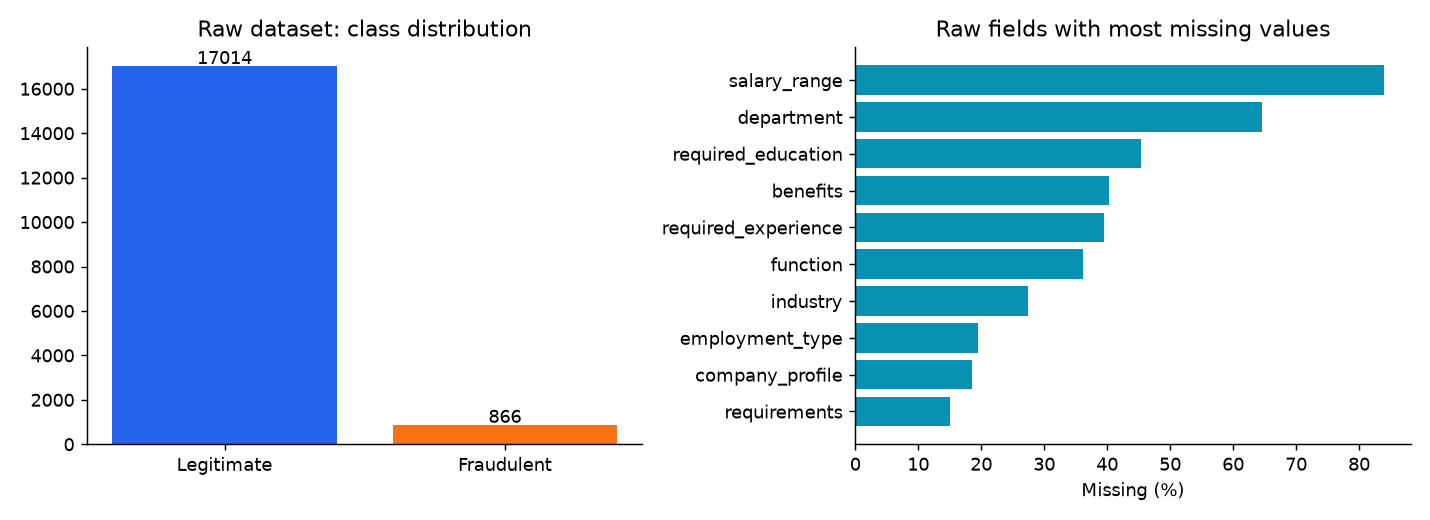

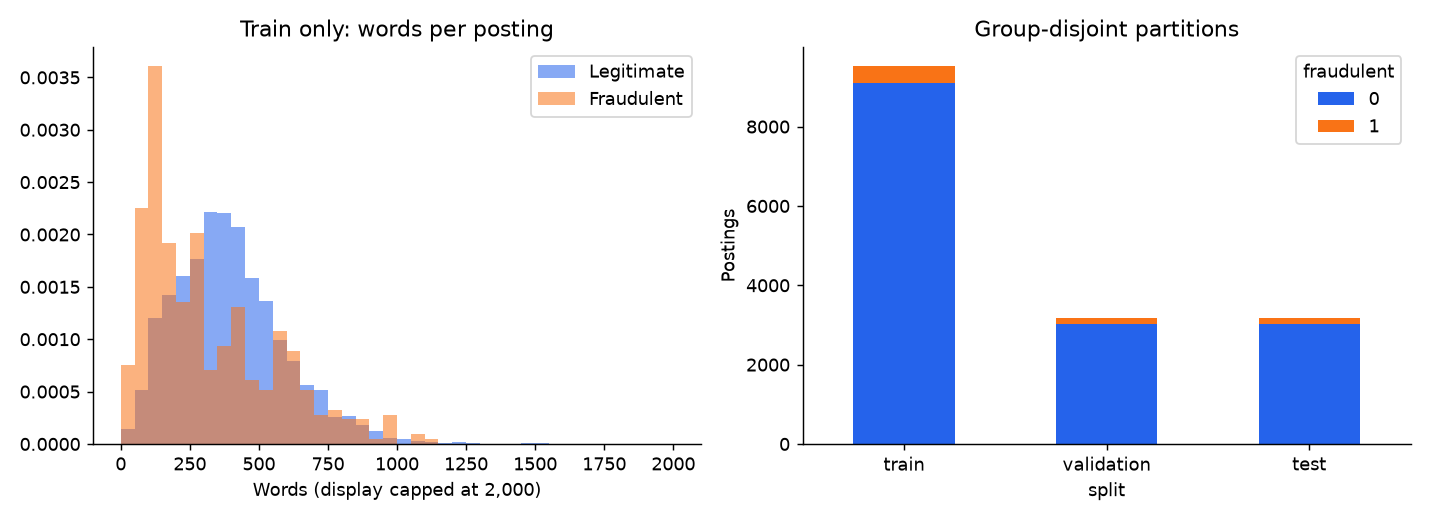

,label,word,count
0,0,experience,21920
1,0,work,18585
2,0,team,17977
3,0,company,13043
4,0,business,11405
5,0,skills,10473
6,0,new,10087
7,0,development,9878
8,0,management,9000
9,0,services,8672


Accuracy nếu luôn đoán hợp lệ trên dữ liệu gốc: 0.9516


In [3]:
display(Image(filename=str(WORK/'results/figures/01_data_overview.png')))
display(Image(filename=str(WORK/'results/figures/02_lengths_splits.png')))
display(pd.read_csv(WORK/'results/top_words_train.csv').groupby('label').head(12))
print('Accuracy nếu luôn đoán hợp lệ trên dữ liệu gốc:', round(ctx['eda']['raw_majority_accuracy'],4))

## 4. Trích xuất đặc trưng và lưu file
**Truyền thống:** BoW; TF-IDF unigram; TF-IDF unigram + bigram; cấu hình có/không loại stopwords.

**Embedding hiện đại theo yêu cầu đề:** GloVe pretrained 50 chiều, trung bình token và trung bình
có trọng số IDF học từ train. Vector cuối được chuẩn hóa L2. Không huấn luyện lại GloVe.
Giới hạn 1.500 token/tin; thống kê số tin bị cắt và độ phủ từ vựng được lưu để phân tích.

File `.npy` chứa embedding; `.npz` chứa ma trận BoW/TF-IDF thưa. `job_ids.npy`, `labels.npy`,
`splits.npy` và `manifest.json` bảo đảm truy vết thứ tự dòng. GloVe pooling mất thứ tự từ,
không tương đương BERT và không tự được tính là phần mở rộng fine-tuning học sâu.

In [4]:
timing = extract_features(ctx)
display(pd.DataFrame(timing).T)
import json
display(json.loads((WORK/'results/embedding_audit.json').read_text(encoding='utf-8')))

Download: glove-wiki-gigaword-50.gz (attempt 1)


Reading pretrained GloVe 50-dimensional vectors...


,seconds,shape,fit
bow,7.706568,"[15872, 32287]",train
tfidf_uni,11.914642,"[15872, 32287]",train
tfidf_bi,27.490288,"[15872, 40000]",train
tfidf_bi_stop,17.718948,"[15872, 40000]",train
glove,28.603257,"[15872, 50]",Frozen pretrained vectors; IDF pooling weights...


{'max_tokens': 1500,
 'truncated_documents': 17,
 'mean_known_token_fraction': 0.9628456234931946,
 'zero_vector_documents': 0,
 'pooling': 'L2-normalized arithmetic mean and train-IDF-weighted mean'}

## 5. Huấn luyện và lựa chọn trên validation
26 cấu hình: BoW + MultinomialNB, TF-IDF + Logistic Regression/Linear SVM,
GloVe + Logistic Regression/Linear SVM. SVM và Logistic Regression dùng class_weight=balanced.

Ngưỡng được chọn theo F1 của lớp gian lận trên validation. Nếu bằng F1, chọn ngưỡng lớn hơn.
Mỗi nhóm giữ một cấu hình tốt nhất; chọn mô hình tổng thể trên validation trước khi đánh giá test.
Quy trình không phải nested cross-validation. Thời gian fit không bao gồm tải dữ liệu/trích xuất đặc trưng.

In [5]:
validation = train_candidates(ctx)
display(validation[['candidate','family','representation','params','f1_fraud','precision_fraud','recall_fraud','average_precision','threshold','fit_seconds','warnings']])
print('Mô hình chọn trước khi xem test:', ctx['selected'])

Train 1/26: bow_nb / bow / {'alpha': 0.1}


Train 2/26: bow_nb / bow / {'alpha': 1.0}


Train 3/26: tfidf_lr / tfidf_uni / {'C': 0.5, 'class_weight': 'balanced'}


Train 4/26: tfidf_svm / tfidf_uni / {'C': 0.5, 'class_weight': 'balanced'}


Train 5/26: tfidf_lr / tfidf_uni / {'C': 2.0, 'class_weight': 'balanced'}


...

Train 24/26: glove_svm / glove_idf / {'C': 1.0, 'class_weight': 'balanced'}


Train 25/26: glove_lr / glove_idf / {'C': 10.0, 'class_weight': 'balanced'}


Train 26/26: glove_svm / glove_idf / {'C': 10.0, 'class_weight': 'balanced'}


,candidate,family,representation,params,f1_fraud,precision_fraud,recall_fraud,average_precision,threshold,fit_seconds,warnings
9,9,tfidf_svm,tfidf_bi,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.707581,0.731343,0.685315,0.726473,-0.367413,1.378659,
7,7,tfidf_svm,tfidf_bi,"{""C"": 0.5, ""class_weight"": ""balanced""}",0.699620,0.766667,0.643357,0.715719,-0.170121,0.844029,
13,13,tfidf_svm,tfidf_bi_stop,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.697479,0.873684,0.580420,0.719501,-0.110962,0.728513,
11,11,tfidf_svm,tfidf_bi_stop,"{""C"": 0.5, ""class_weight"": ""balanced""}",0.692308,0.890110,0.566434,0.709884,0.034425,0.558875,
5,5,tfidf_svm,tfidf_uni,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.684211,0.739837,0.636364,0.703287,-0.280961,0.495506,
3,3,tfidf_svm,tfidf_uni,"{""C"": 0.5, ""class_weight"": ""balanced""}",0.683544,0.861702,0.566434,0.702951,0.004541,0.744168,
12,12,tfidf_lr,tfidf_bi_stop,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.666667,0.810000,0.566434,0.677066,0.584659,0.471877,
8,8,tfidf_lr,tfidf_bi,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.654275,0.698413,0.615385,0.681643,0.444698,0.644643,
4,4,tfidf_lr,tfidf_uni,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.651341,0.720339,0.594406,0.677762,0.511992,0.323770,
10,10,tfidf_lr,tfidf_bi_stop,"{""C"": 0.5, ""class_weight"": ""balanced""}",0.648000,0.757009,0.566434,0.645718,0.573472,0.372201,


Mô hình chọn trước khi xem test: 9


## 6. Đánh giá test giữ riêng
Accuracy phải đọc cùng precision, recall, F1 của lớp gian lận và average precision (AP).
AP là tóm tắt đường precision-recall, không phải diện tích hình thang.
- False positive: tin hợp lệ bị cảnh báo nhầm.
- False negative: tin gian lận bị bỏ sót.
Các dòng đánh giá dưới đây đều là cấu hình đã chốt bằng validation. Không đổi lựa chọn sau bảng này.

Completed in 122.8 seconds.


,candidate,family,representation,threshold,selected_on_validation,accuracy,precision_fraud,recall_fraud,f1_fraud,average_precision,roc_auc,tn,fp,fn,tp
0,-1,majority_baseline,none,1.000000,False,0.954961,0.000000,0.000000,0.000000,0.045039,0.500000,3032,0,143,0
1,9,tfidf_svm,tfidf_bi,-0.367413,True,0.960945,0.571429,0.531469,0.550725,0.534807,0.865322,2975,57,67,76
2,12,tfidf_lr,tfidf_bi_stop,0.584659,False,0.963780,0.655556,0.412587,0.506438,0.501527,0.850467,3001,31,84,59
3,0,bow_nb,bow,0.998391,False,0.945827,0.394161,0.377622,0.385714,0.332112,0.812851,2949,83,89,54
4,14,glove_lr,glove_mean,0.820542,False,0.890709,0.143357,0.286713,0.191142,0.137441,0.713792,2787,245,102,41
5,21,glove_svm,glove_idf,0.615513,False,0.916220,0.190955,0.265734,0.222222,0.142413,0.724590,2871,161,105,38


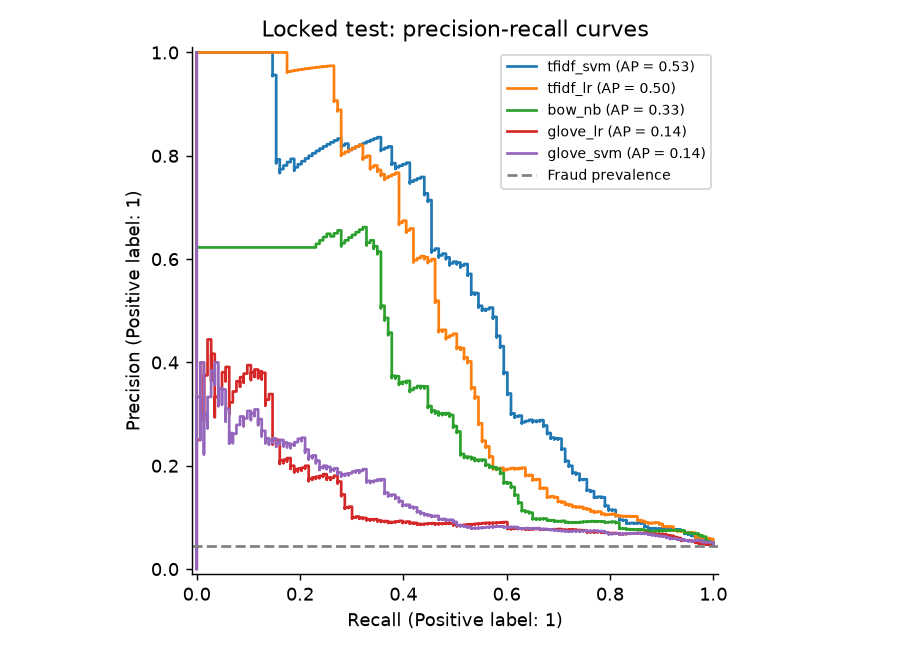

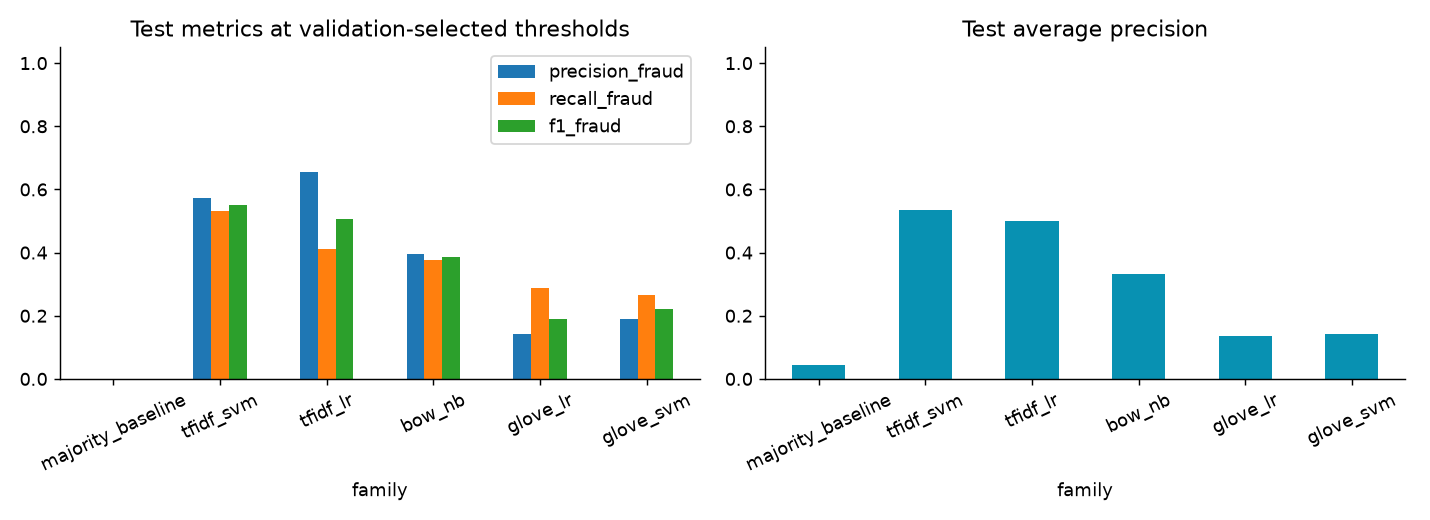

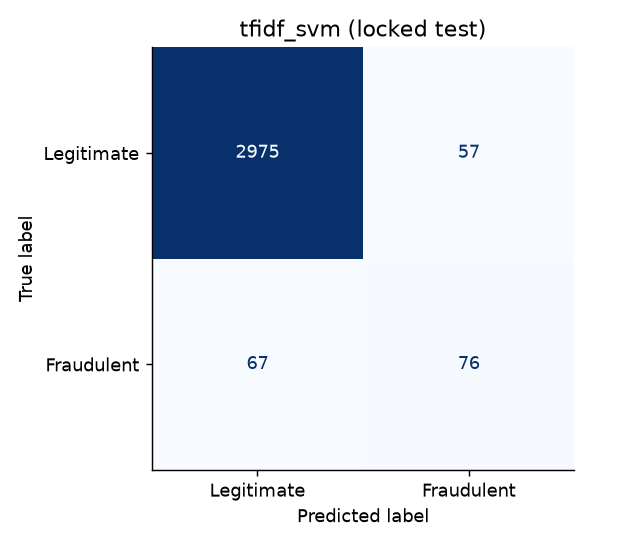

In [6]:
test_results = evaluate_test(ctx)
display(test_results)
display(Image(filename=str(WORK/'results/figures/03_precision_recall.png')))
display(Image(filename=str(WORK/'results/figures/04_model_comparison.png')))
selected_family = ctx['candidates'][ctx['selected']]['record']['family']
display(Image(filename=str(WORK/f'results/figures/cm_{selected_family}.png')))

## 7. Pipeline deep learning mở rộng: TextCNN

TextCNN học embedding và các bộ lọc tích chập trực tiếp từ văn bản train. Mô hình dùng convolution
với kernel 3/4/5, global max pooling và dropout. Epoch tốt nhất cùng ngưỡng cảnh báo chỉ được chọn
trên validation; test được đọc đúng một lần sau khi khóa lựa chọn. Đây là phần mở rộng deep learning
thật sự để so sánh với pipeline truyền thống, không phải GloVe pooling cố định.

GPU giúp chạy nhanh hơn nhưng Colab CPU vẫn có thể chạy. Nếu chạy notebook local trên Python chưa
hỗ trợ PyTorch, phần này được bỏ qua có thông báo; trên Google Colab, PyTorch được cài tự động nếu thiếu.

TextCNN epoch 1/6: loss=1.0944, val_f1=0.3931, val_ap=0.3736


TextCNN epoch 2/6: loss=0.6532, val_f1=0.4098, val_ap=0.4039


TextCNN epoch 3/6: loss=0.3744, val_f1=0.4790, val_ap=0.4658


TextCNN epoch 4/6: loss=0.3353, val_f1=0.5106, val_ap=0.5053


TextCNN epoch 5/6: loss=0.2378, val_f1=0.5323, val_ap=0.5371


TextCNN epoch 6/6: loss=0.1795, val_f1=0.5547, val_ap=0.5659


,split,family,threshold,accuracy,precision_fraud,recall_fraud,f1_fraud,average_precision,roc_auc,tn,fp,fn,tp
0,validation,textcnn,0.601941,0.964094,0.628319,0.496503,0.554688,0.565920,0.889244,2990,42,72,71
1,test,textcnn,0.601941,0.957480,0.537736,0.398601,0.457831,0.489012,0.872797,2983,49,86,57


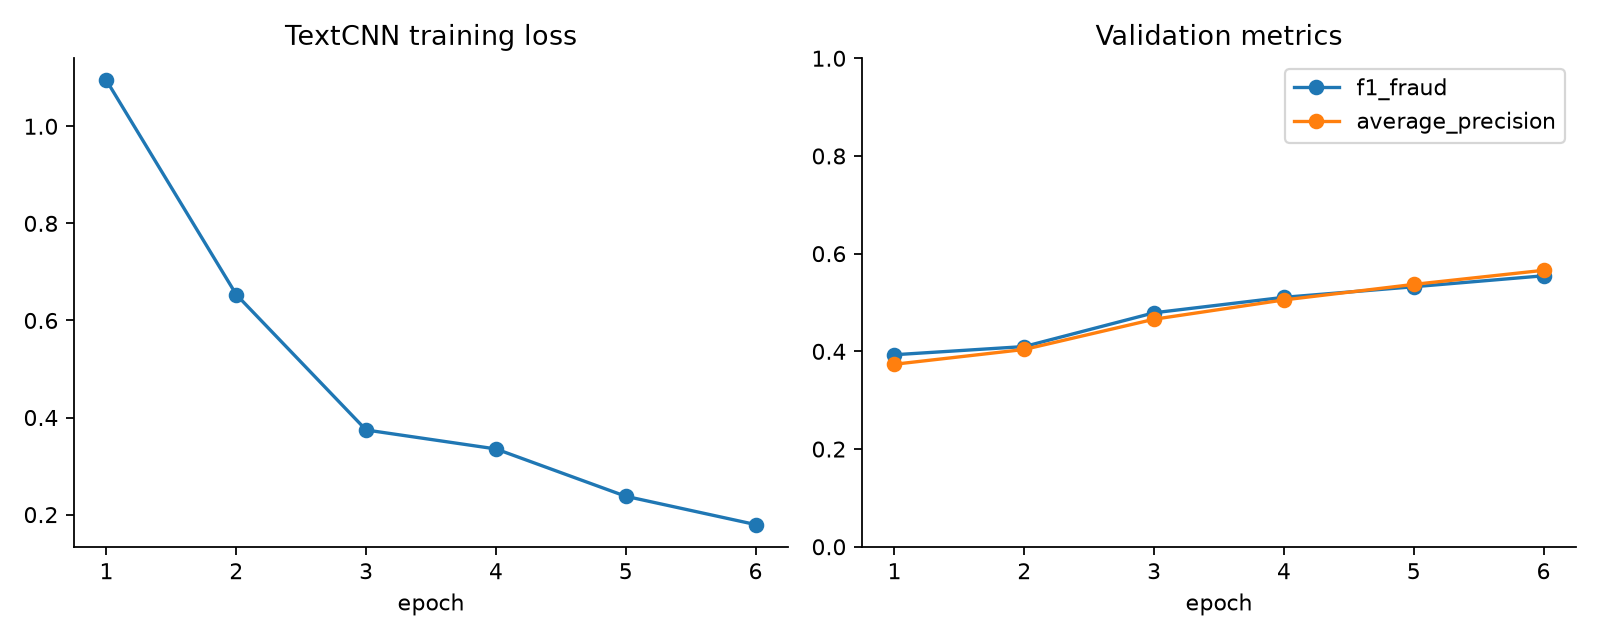

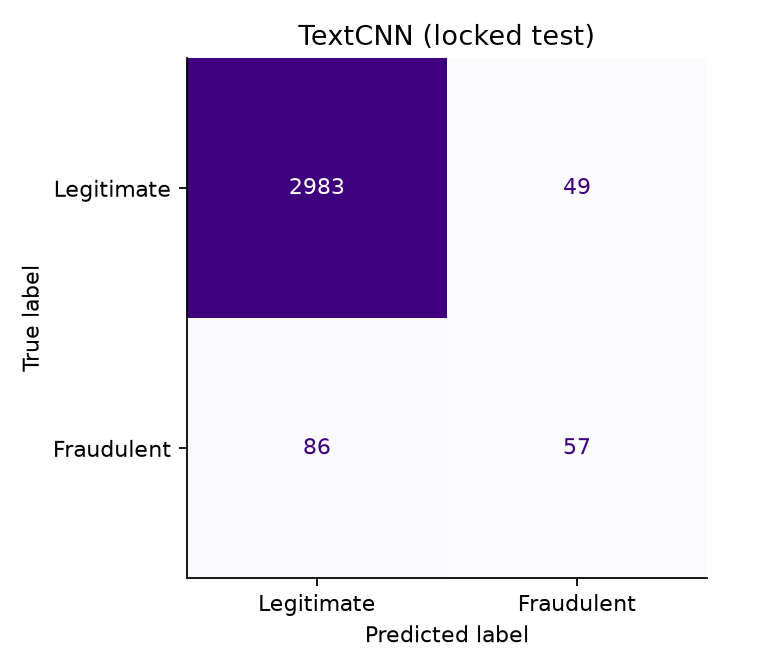

,family,f1_fraud,average_precision
1,tfidf_svm,0.550725,0.534807
2,tfidf_lr,0.506438,0.501527
6,textcnn,0.457831,0.489012
3,bow_nb,0.385714,0.332112
5,glove_svm,0.222222,0.142413
4,glove_lr,0.191142,0.137441
0,majority_baseline,0.000000,0.045039


In [7]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('torch') is None and IS_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'torch>=2.2,<3'])
if importlib.util.find_spec('torch') is None:
    deep_results = None
    print('Bỏ qua TextCNN ở môi trường local vì chưa có PyTorch. Hãy chạy notebook trên Colab.')
else:
    from modules.deep_learning import run_textcnn
    deep_results = run_textcnn(ctx, epochs=6, batch_size=128)
    display(deep_results)
    display(Image(filename=str(WORK/'results/figures/05_textcnn_training.png')))
    display(Image(filename=str(WORK/'results/figures/cm_textcnn.png')))
    traditional = test_results[['family','f1_fraud','average_precision']].copy()
    deep_test = deep_results.loc[deep_results['split']=='test', ['family','f1_fraud','average_precision']]
    display(pd.concat([traditional, deep_test], ignore_index=True).sort_values('f1_fraud', ascending=False))

## 8. Phân tích lỗi
Xem tin bị bỏ sót và cảnh báo nhầm để nhận xét giới hạn. Không dùng các lỗi test này để
sửa mô hình rồi báo lại cùng test như một kết quả độc lập.

In [8]:
errors = pd.read_csv(WORK/f'results/errors/{selected_family}.csv')
display(errors[['job_id','error_type','title','score','text_excerpt']].groupby('error_type').head(3))

,job_id,error_type,title,score,text_excerpt
0,181,false_negative,Sales Executive,-0.977044,sales executive sales executive sales executiv...
1,430,false_positive,Accounting Assistant,-0.359769,accounting assistant crossroads staffing dedic...
2,442,false_positive,Account Manager/CSR -insurance agency,-0.025041,account manager/csr -insurance agency anderson...
3,616,false_positive,Telesales Advisor,-0.142846,telesales advisor working at assurelife we wil...
5,844,false_negative,Technical & Customer Support Associates,-0.588228,technical & customer support associates the ac...
6,846,false_negative,Service Associate,-0.795626,service associate the accion story began more ...


## 9. Demo giải thích dự đoán
Demo dùng **TF-IDF + Logistic Regression tốt nhất trên validation**, có thể khác mô hình thắng
tổng thể. Điểm mô hình chưa được hiệu chuẩn thành xác suất thực tế.
Cụm từ hiển thị là đóng góp vào log-odds của mô hình tuyến tính, không phải nguyên nhân hay bằng chứng gian lận.
Tin tiếng Việt và các cách lừa đảo hiện nay nằm ngoài phạm vi đã kiểm chứng.

In [9]:
from modules.inference import predict_text, notebook_demo
example = 'We are looking for a software engineer to develop Python applications, review code and collaborate with our engineering team. Applicants should have experience with databases and automated testing.'
result, towards_fraud, towards_legitimate = predict_text(example, WORK)
display(result)
display(towards_fraud)
print('Đây là ví dụ minh họa tự viết, không có nhãn thật và không tham gia đánh giá.')
demo_widgets = notebook_demo(WORK)

{'decision': 'Chưa vượt ngưỡng cảnh báo',
 'model_score': 0.16309765487690658,
 'threshold': 0.5846591801980155,
 'model': 'TF-IDF + Logistic Regression',
 'candidate': 12,
 'matched_features': 20,
 'note': 'Điểm mô hình chưa được hiệu chuẩn. Cụm từ ảnh hưởng dự đoán không phải bằng chứng gian lận. Chỉ đánh giá trên tiếng Anh lịch sử.'}

,term,contribution_to_log_odds
9,engineering,0.336038
0,applicants,0.233353
10,engineering team,0.164118
8,engineer,0.149807
13,looking software,0.123710
4,code,0.105123
12,looking,0.033411
6,databases,0.005662


Đây là ví dụ minh họa tự viết, không có nhãn thật và không tham gia đánh giá.


Textarea(value='', layout=Layout(height='190px', width='100%'), placeholder='Paste an English job posting here…

Button(button_style='primary', description='Phân tích tin', style=ButtonStyle())

Output()

## 10. Kiểm tra và đóng gói
Kiểm tra tính tách biệt nhóm, thứ tự embedding, SHA-256, cách chọn mô hình và tính lại chỉ số từ dự đoán.
ZIP gồm notebook nguồn, modules, features, models, results và báo cáo PDF trong `reports/`.
Dữ liệu thô và GloVe tự tải lại, không đưa vào ZIP.

In [10]:
import unittest
suite = unittest.defaultTestLoader.discover(str(WORK/'tests'), pattern='test_*.py')
test_run = unittest.TextTestRunner(verbosity=2).run(suite)
assert test_run.wasSuccessful(), 'Kiểm tra pipeline thất bại'
from tools.build_notebook import build_notebook
from tools.package import package
build_notebook(WORK)
archive_path = package(WORK)
print('Gói dự án:', archive_path)
print('Báo cáo PDF:', WORK/'reports/job_scam_report.pdf')

test_demo_rejects_empty_input_and_explanation_is_exact (test_pipeline.ArtifactTests.test_demo_rejects_empty_input_and_explanation_is_exact) ... 

ok


test_partition_and_feature_alignment (test_pipeline.ArtifactTests.test_partition_and_feature_alignment) ... 

ok


test_selection_and_reported_metrics (test_pipeline.ArtifactTests.test_selection_and_reported_metrics) ... 

...

ok


test_transitive_grouping_and_blank_profiles (test_pipeline.CoreTests.test_transitive_grouping_and_blank_profiles) ... 

ok


----------------------------------------------------------------------
Ran 7 tests in 0.538s

OK


Gói dự án: D:\ML\tmp\notebook_validation\work_jm14z4jx\output\job_scam_project.zip
Báo cáo PDF: D:\ML\tmp\notebook_validation\work_jm14z4jx\reports\job_scam_report.pdf


### Tải file trên Colab (tùy chọn)
Trong thanh Files bên trái, mở `job_scam_project/output`, chọn tải `job_scam_project.zip`.
Notebook đang mở có thể lưu thêm bằng **File → Download → Download .ipynb** để giữ output lần chạy.

## Nguồn tham khảo
1. Vidros et al. (2017). [EMSCAD và phát hiện gian lận tuyển dụng](https://doi.org/10.3390/fi9010006).
2. [Bản dữ liệu công khai trên Kaggle](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction).
3. Pennington et al. (2014). [GloVe](https://nlp.stanford.edu/projects/glove/).
4. [Gensim-data, nguồn phân phối vector GloVe](https://github.com/piskvorky/gensim-data).
5. [Scikit-learn: đánh giá mô hình](https://scikit-learn.org/stable/modules/model_evaluation.html).

## Những việc còn lại trước khi nộp
Điền họ tên/MSSV/email/mã môn; xác nhận được làm cá nhân và dataset chưa trùng;
kiểm tra Run all trên Colab bằng tài khoản của người nộp; bổ sung liên kết
GitHub/Colab khi đã tạo. Không có minh chứng họp nhóm hoặc lịch sử làm việc giả định.